# MAQT Prototypes: UNSW-NB15
## ... Training (Weighted) | Batch Size ... | ... Epochs | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_EPOCHS, DEFAULT_LR, DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, DEFAULT_NOISE_RATE,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y
from scripts.logging import write_history_log
from scripts.prototypes import prototype_summary

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: UNSW-NB15

In [4]:
NOTEBOOK_NAME = "14.maqt-prototypes_unsw-nb15"
dataset = "UNSW-NB15"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Analysis',
 'Backdoor',
 'DoS',
 'Exploits',
 'Fuzzers',
 'Generic',
 'Normal',
 'Reconnaissance']

In [8]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape]

[(71094, 8), (71094,)]

## EDA (Before Subset)

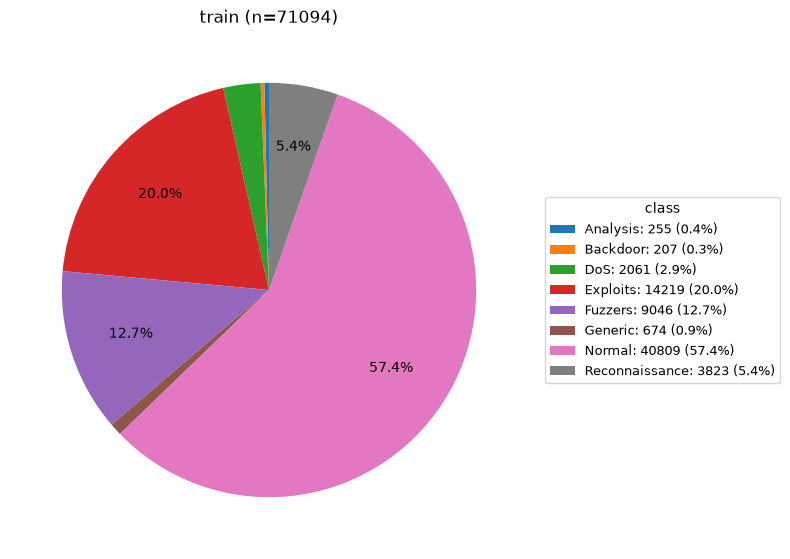

In [10]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train_full, class_names,
    title=f"train (n={len(to_np_y(y_train_full))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Data Subset

In [11]:
SUBSET = True # set to False for the full dataset
SEED = 42

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, 5, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(40, 8), (40,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 8
number of qubits: 8


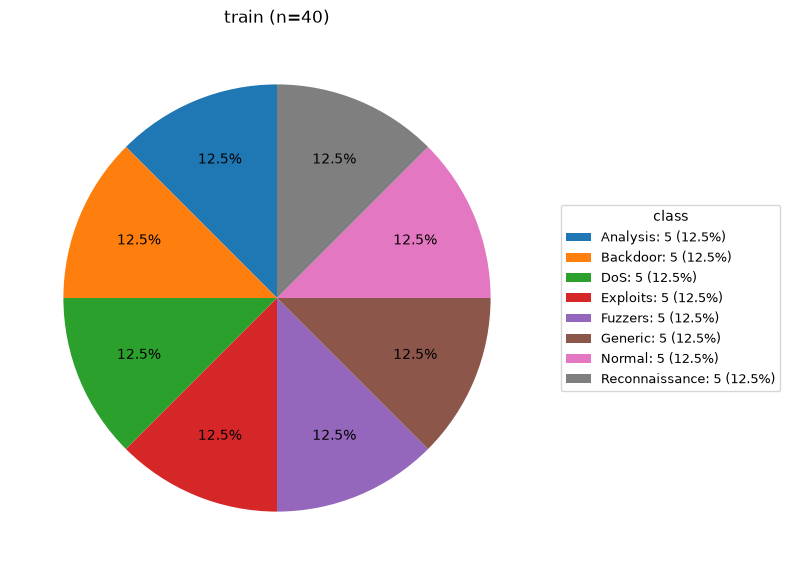

In [14]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train, class_names,
    title=f"train (n={len(to_np_y(y_train))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [15]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Gradient Variance Probe

In [17]:
from scripts.gradient import gradient_variance_probe
from scripts.constants import BARREN_PLATEAU_VAR_THRESHOLD, DEFAULT_N_TRIALS

barren_plateau_var = BARREN_PLATEAU_VAR_THRESHOLD
n_trials = DEFAULT_N_TRIALS

In [18]:
# small probe batch from train
x_probe = X_train[: min(8, len(X_train))]

var, grad_samples = gradient_variance_probe(
    forward_circuit, x_probe, num_qubits, num_layers,
    n_trials=n_trials, device=device,
)

print(f"pre-train grad var = {var:.2e} (thr={barren_plateau_var:.0e})")
if var < barren_plateau_var:
    print("warning: possible barren plateau architecture")

pre-train grad var = 1.18e-07 (thr=1e-06)


## Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [19]:
epochs = 3
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2

In [20]:
theta, head, prototypes, ema_protos, history = train_maqt(
    X_train, y_train,
    n_classes=num_classes,
    n_qubits=num_qubits,
    n_layers=num_layers,
    forward_circuit=forward_circuit,
    device=device,
    epochs=epochs,
    lr=lr,
    batch_size=batch_size,
    lambda1_max=lambda1,
    lambda2_max=lambda2,
    use_weighted_sampler=True,
)

theta_star = theta
classifier_head = head

epoch  1/3 | loss 2.0804 | L_CE 2.0804 | L_intra 0.0000 | L_inter 0.0000 | grad_var 4.35e-05 | intra_fid 1.000 | inter_TD 0.480 | time 5.0s
epoch  2/3 | loss 1.9778 | L_CE 1.9842 | L_intra 0.2752 | L_inter -0.4800 | grad_var 9.09e-05 | intra_fid 0.725 | inter_TD 0.472 | time 9.4s
epoch  3/3 | loss 2.0231 | L_CE 2.0136 | L_intra 0.3022 | L_inter -0.4722 | grad_var 1.94e-04 | intra_fid 0.698 | inter_TD 0.466 | time 9.4s


## Prototypes

In [21]:
proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

,class,dim,trace
0,Analysis,256,1.000001
1,Backdoor,256,1.000001
2,DoS,256,1.000001
3,Exploits,256,1.000001
4,Fuzzers,256,1.000001
5,Generic,256,1.000000
6,Normal,256,1.000000
7,Reconnaissance,256,1.000000


In [22]:
# save prototypes (all-in-one checkpoint)
out_dir = Path("models/prototypes") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "theta": theta_star.detach().cpu(),
        "head_state_dict": head.state_dict(),
        "prototypes": {k: v.detach().cpu() for k, v in prototypes.items()},
        
        # minimal rebuild / inference meta
        "class_names": list(class_names),
        "num_classes": num_classes,
        "num_qubits": num_qubits,
        "num_layers": num_layers,
        "noise_rate": noise_rate,
    },
    out_dir / f"{NOTEBOOK_NAME}-checkpoint.pt",
)
print("published:", out_dir.resolve())

published: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/UNSW-NB15


## Visualization

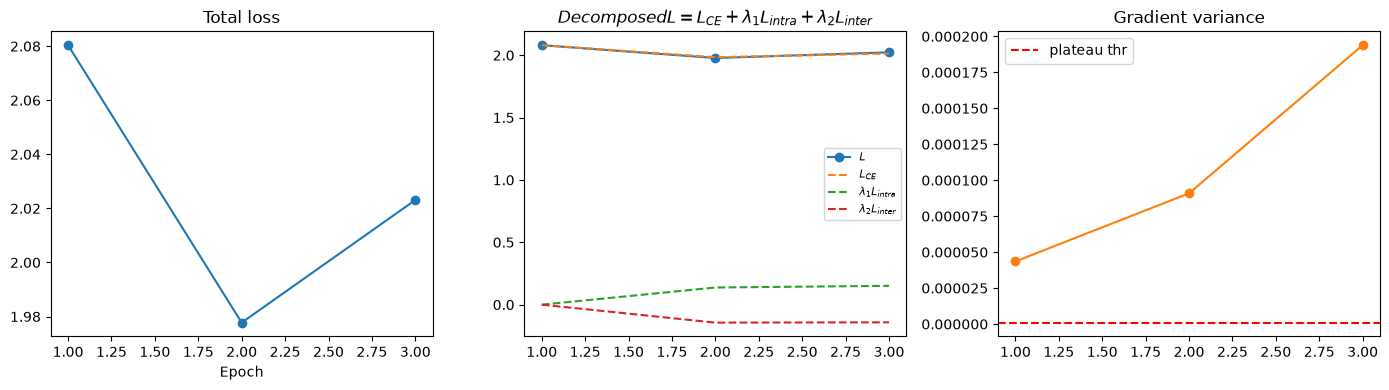

In [23]:
# plots
epochs_x = range(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# total loss
axes[0].plot(epochs_x, history["loss"], marker="o")
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch")

# decomposed (weighted like the objective)
axes[1].plot(epochs_x, history["loss"], marker="o", label=r"$L$")
axes[1].plot(epochs_x, history["L_CE"], "--", label=r"$L_{CE}$")
axes[1].plot(epochs_x, [lambda1 * v for v in history["L_intra"]], "--", label=r"$\lambda_1 L_{intra}$")
axes[1].plot(epochs_x, [lambda2 * v for v in history["L_inter"]], "--", label=r"$\lambda_2 L_{inter}$")
axes[1].set_title(r"$Decomposed L = L_{CE}+\lambda_1 L_{intra}+\lambda_2 L_{inter}$")
axes[1].legend(fontsize=8)

# grad var
axes[2].plot(epochs_x, history["grad_var"], marker="o", color="tab:orange")
axes[2].axhline(1e-6, color="red", linestyle="--", label="plateau thr")  # or BARREN_PLATEAU_VAR_THRESHOLD
axes[2].set_title("Gradient variance")
axes[2].legend()

plt.tight_layout()
plt.show()

## Logging

In [24]:
for k in history.keys():
    print(k)

loss
L_CE
L_intra
L_inter
grad_var
intra_fid_gap
inter_trace_dist
epoch_sec


In [25]:
# write log (final)
log_path = write_history_log(
    history,
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": "q8",
        "target_col": target_col,
        "n_train": len(X_train),
        "class_names": list(class_names),
        
        # algo 1: MAQT train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "use_weighted_sampler": True,

        ## quantum model
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_qubits": num_qubits,
        "num_classes": num_classes,

        ## training
        "train_total_sec": float(sum(history["epoch_sec"])) if history.get("epoch_sec") else None,       
        "loss_last": float(history["loss"][-1]) if history["loss"] else None,
        "barren_plateau_var": barren_plateau_var,
        "barren_plateau_any": bool(
            any(g < barren_plateau_var for g in history["grad_var"])
        ) if history["grad_var"] else None,
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/14.maqt-prototypes_unsw-nb15.log
